# Notebook to develop codes:

**Remark:** 
 * I work in my local branch (edmond-dev)
 * For now it turns with `desilike/dr2-dev`

In [6]:
"""
Script to fit png from the data.
"""

import logging

import os
from pathlib import Path
import functools

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')


# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [7]:
from tools import read_data, rebin_data, get_obervable_and_likelihood, plot_observables, run_profiler, run_mcmc, plot_triangle

from tools import combine_analytical_covariances 

def plot_corr(cov, fn=None): 
    import matplotlib.text
    import re
    
    fig = cov.plot(corrcoef=True, figsize=(9,9))
    for txt in fig.findobj(matplotlib.text.Text):
        s = txt.get_text()
        s = s.replace('spectrum2,', '').replace(',spectrum2', '').replace('spectrum2', '')
        s = re.sub(r'\b(\w+)_\1\b', r'\1', s)   # LRG_LRG -> LRG
        s = s.replace('_', 'x')                 # LRG_QSO -> LRGxQSO
        s = s.replace('\nx ', '\n')             # remove "x " prefix on second line
        if '\n' in s: txt.set_fontsize(8)
        txt.set_text(s)
    if fn is not None: plt.savefig(fn)
    plt.show()

In [8]:
from clustering_statistics import setup_logging

from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

#stats_dir = Path(os.getenv('SCRATCH', '.')) / 'DR2_local_png' / 'measurements' / 'loa-v1/v2/fNL'
stats_dir =  Path('/Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/')

if True:
    stats_dir = stats_dir / 'blinded'
else:
    logger.error('NOT READY FOR UNBLINDED DATA YET')
    import sys
    sys.exit(3)

logger.info(f'Load data from: stats_dir: {stats_dir}')

[000000.00] [0/1] 04-10 18:25  FIT PNG                   INFO     Load data from: stats_dir: /Users/edmond/Work/data/desi/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded


In [9]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08}
    propose_fiducial['ELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 8e-3, 'kmax': 0.08} 
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08}   
    propose_fiducial['LRGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 1e-3, 'kmax': 0.08}   
    propose_fiducial['LRGxELG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 5e-3, 'kmax': 0.08}   
    propose_fiducial['ELGxQSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.6), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 5e-3, 'kmax': 0.08}   
    # when sort tracer name, ELG arrive first, so it is convienient to have it here as well 
    propose_fiducial['ELGxLRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 1.1), 'region': 'GCcomb', 'use_ell2': True, 'kmin': 5e-3, 'kmax': 0.08}  
    return propose_fiducial

fiducial = propose_fiducial()
tracers_to_read = ['LRG', 'ELGnotqso', 'QSO', 'LRGxQSO', 'LRGxELGnotqso', 'ELGnotqsoxQSO'] 

pks, windows, covs, zeffs = {}, {}, {}, {}
for tracer in tracers_to_read:
    short_tracer = tracer.replace('_zcmb', '')
    short_tracer = short_tracer.replace('notqso', '')

    pk, window, cov = read_data(stats_dir=stats_dir, tracer=tracer, **fiducial[short_tracer])
    pk, window, cov = rebin_data(pk, window, cov, tracer=tracer, **fiducial[short_tracer])
    try: 
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} and {pk.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk.get(0).k.shape[0]} data points.')
   
    if 'x' not in short_tracer: short_tracer = 'x'.join(2*[short_tracer])
    pks[short_tracer], windows[short_tracer], covs[short_tracer] = pk, window, cov

    zeffs[short_tracer] = {}
    zeffs[short_tracer][0] = windows[short_tracer].observable.get(0).attrs['zeff']
    try: 
        zeffs[short_tracer][2] = windows[short_tracer].observable.get(2).attrs['zeff']
    except KeyError:
        pass

[000000.51] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 49 and 25 data points.
[000000.54] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 42 and 21 data points.
[000000.62] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 49 and 25 data points.
[000000.69] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 49 and 25 data points.
[000000.76] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 45 and 23 data points.
[000000.82] [0/1] 04-10 18:25  FIT PNG                   INFO     After rebinning and k range selection: 45 and 23 data points.


In [ ]:
tracers = ['LRGxLRG', 'ELGxELG', 'QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO'] 

# just to have a coherent value of b1 in the cross correlation.
kwargs = {'LRG_cross_ell0.b1': 2.15, 'ELG_cross_ell0.b1': 1.2}

observables, likelihoods, profilers = {}, {}, {}
for tracer in tracers:
    observables[tracer], likelihoods[tracer] = get_obervable_and_likelihood(pks[tracer], windows[tracer], covs[tracer], tracer, zeffs, engine='camb', **kwargs)
    profilers[tracer] = run_profiler(likelihoods[tracer])

[000001.74] [0/1] 04-10 18:25  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[000001.83] [0/1] 04-10 18:25  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[000003.33] [0/1] 04-10 18:25  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000003.57] [0/1] 04-10 18:25  MinuitProfiler            INFO     Successfully jit input likelihood.
[000005.43] [0/1] 04-10 18:25  PNG fitting tools         INFO     
+-------------------------------------+--------+---------+-------+
| chi2 / (74 - 4) = 76.69 / 70 = 1.10 | varied | bestfit | error |
+-------------------------------------+--------+---------+-------+
|               fnl_loc               |  True  |   2.3   |  4.1  |
|            LRG_ell0.sn0             |  True  |  0.017  | 0.050 |
|             LRG_ell0.b1             |  True  |  2.142  | 0.024 |
|           LRG_ell0.sigmas           |  True  |  3.55   | 

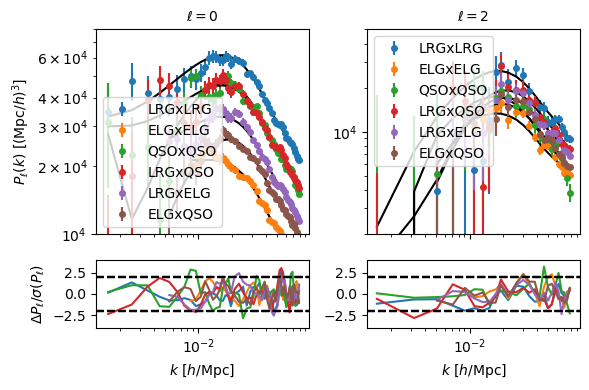

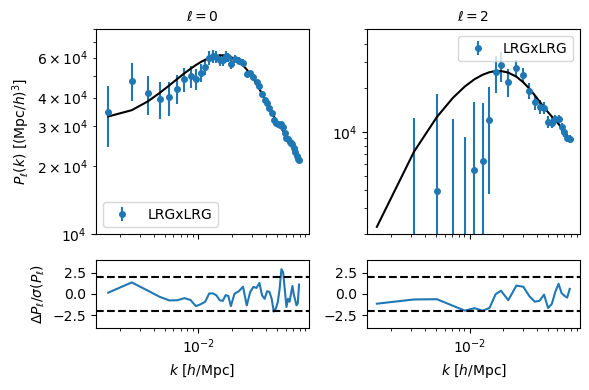

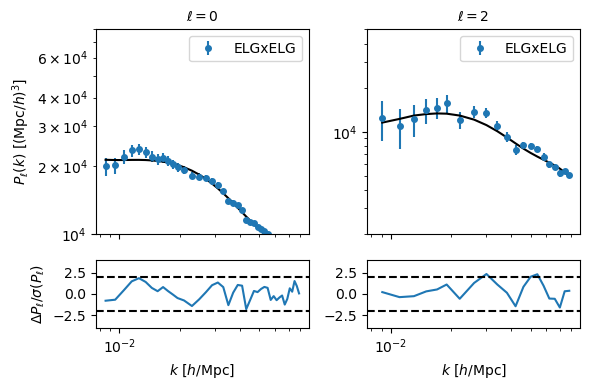

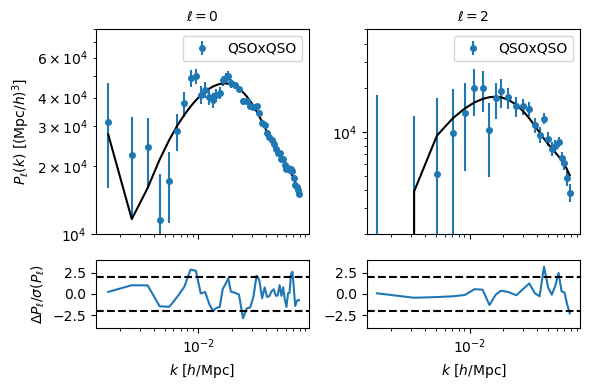

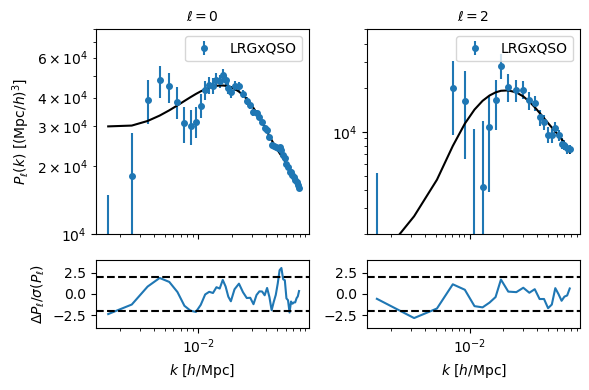

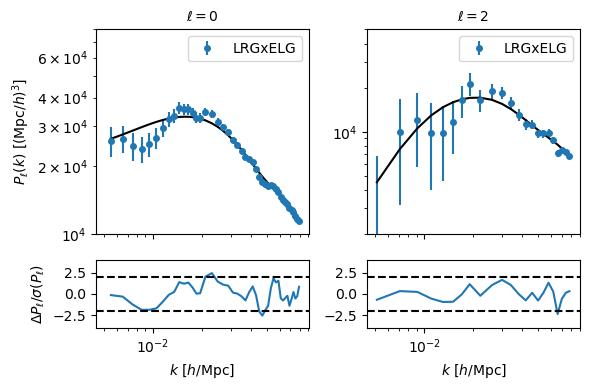

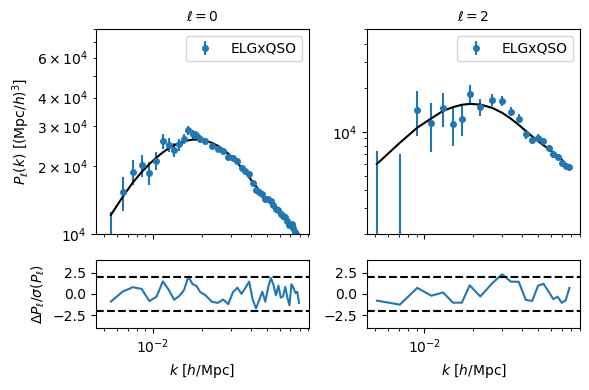

In [ ]:
plot_observables(observables)
#for tracer in observables.keys():
#    plot_observables({tracer: observables[tracer]})

In [17]:
def build_total_likelihood(order, observables, covs, zeffs, fiducial=fiducial, plot_cov=False):
    from desilike.likelihoods import ObservablesGaussianLikelihood
    from tools import combine_analytical_covariances, fix_likelihood_bias_and_damping

    total_observables = [observable for tracer in order for observable in observables[tracer]]
    logger.debug([ff.name for ff in total_observables])

    total_cov = combine_analytical_covariances(pks, covs, order=order, fiducial=fiducial)
    logger.debug(total_cov.observable)
    if plot_cov:
        plot_corr(total_cov, fn='fig/analytical_correlation_matrix.pdf')
    
    total_likelihood = ObservablesGaussianLikelihood(observables=total_observables, covariance=total_cov.value(), scale_covariance=1)
    for tracer in order: 
        fix_likelihood_bias_and_damping(total_likelihood, tracer=tracer, zeffs=zeffs, derived_cross_bias=True)
    
    return total_likelihood

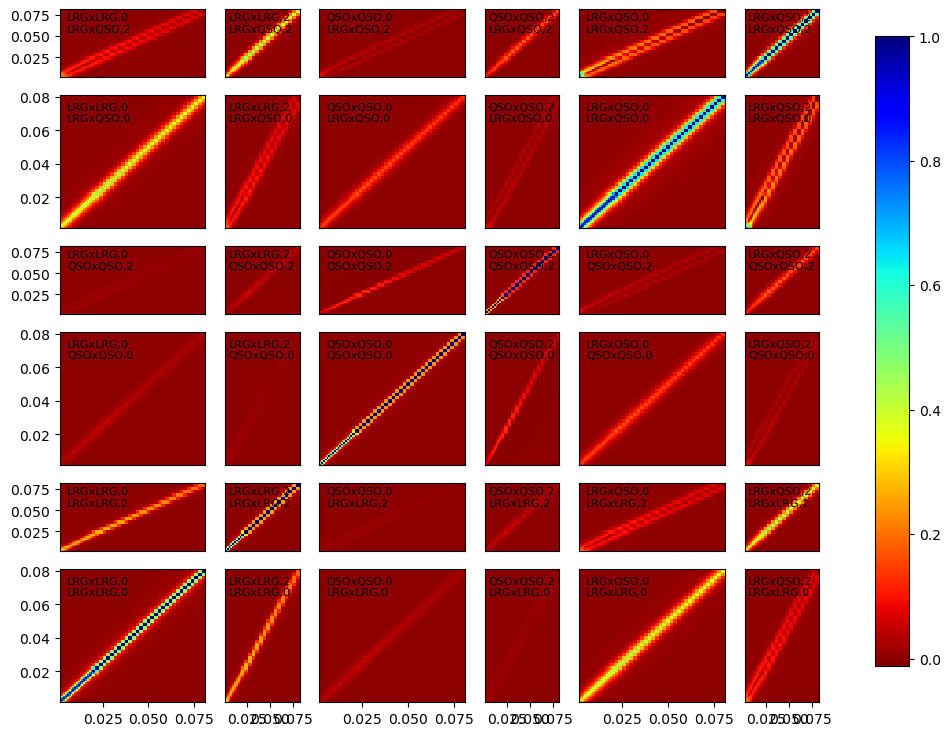

[000730.82] [0/1] 04-10 18:37  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000731.43] [0/1] 04-10 18:37  MinuitProfiler            INFO     Successfully jit input likelihood.
[000745.62] [0/1] 04-10 18:38  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (222 - 9) = 290.29 / 213 = 1.36 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |  -9.2   |  2.1  |
|   LRG_cross_ell0xQSO_cross_ell0.sn0    |  True  | -0.046  | 0.036 |
|         QSO_cross_ell0.sigmas          |  True  |   2.8   |  1.9  |
|              QSO_ell0.sn0              |  True  | -0.182  | 0.039 |
|              QSO_ell0.b1               |  True  |  3.224  | 0.034 |
|           

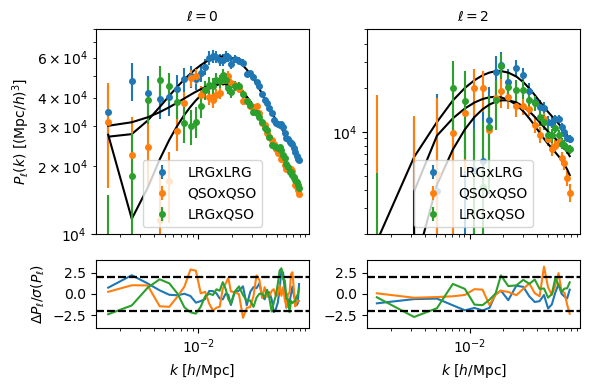

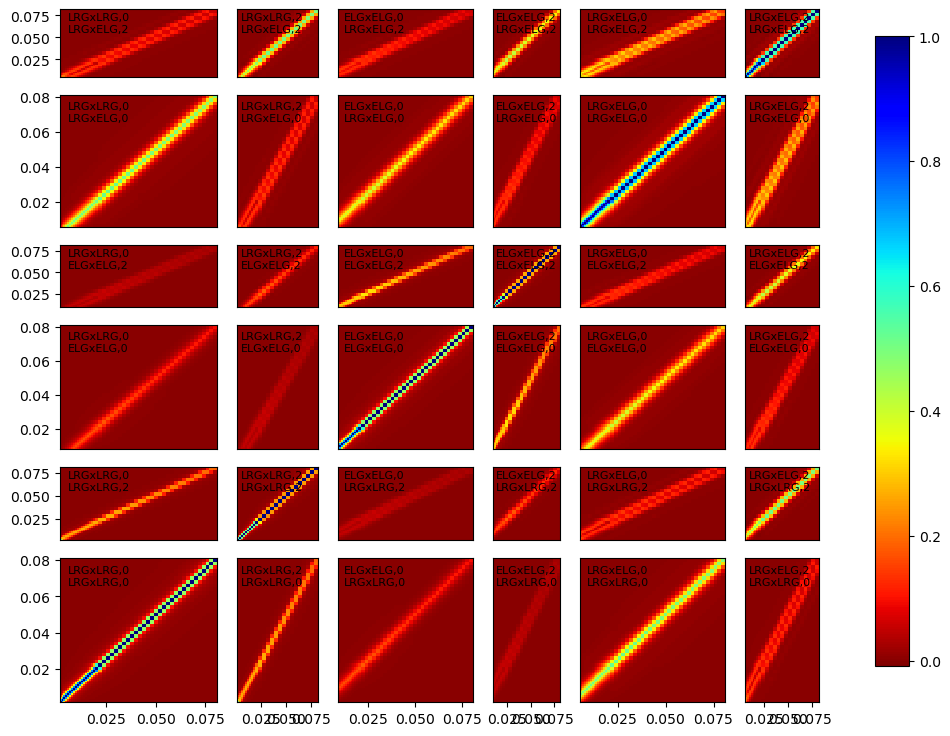

[000748.16] [0/1] 04-10 18:38  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xELG_cross_ell0.sn0', 'ELG_cross_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[000748.79] [0/1] 04-10 18:38  MinuitProfiler            INFO     Successfully jit input likelihood.
[000765.38] [0/1] 04-10 18:38  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 244.36 / 196 = 1.25 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |   3.0   |  3.7  |
|   LRG_cross_ell0xELG_cross_ell0.sn0    |  True  |  0.011  | 0.022 |
|         ELG_cross_ell0.sigmas          |  True  |  7.88   | 0.40  |
|              ELG_ell0.sn0              |  True  |  0.045  | 0.016 |
|              ELG_ell0.b1               |  True  |  1.371  | 0.017 |
|           

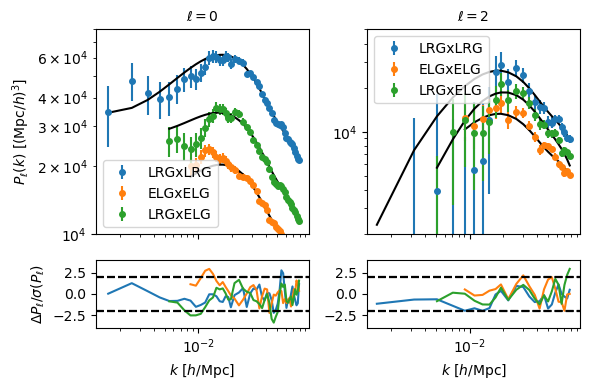

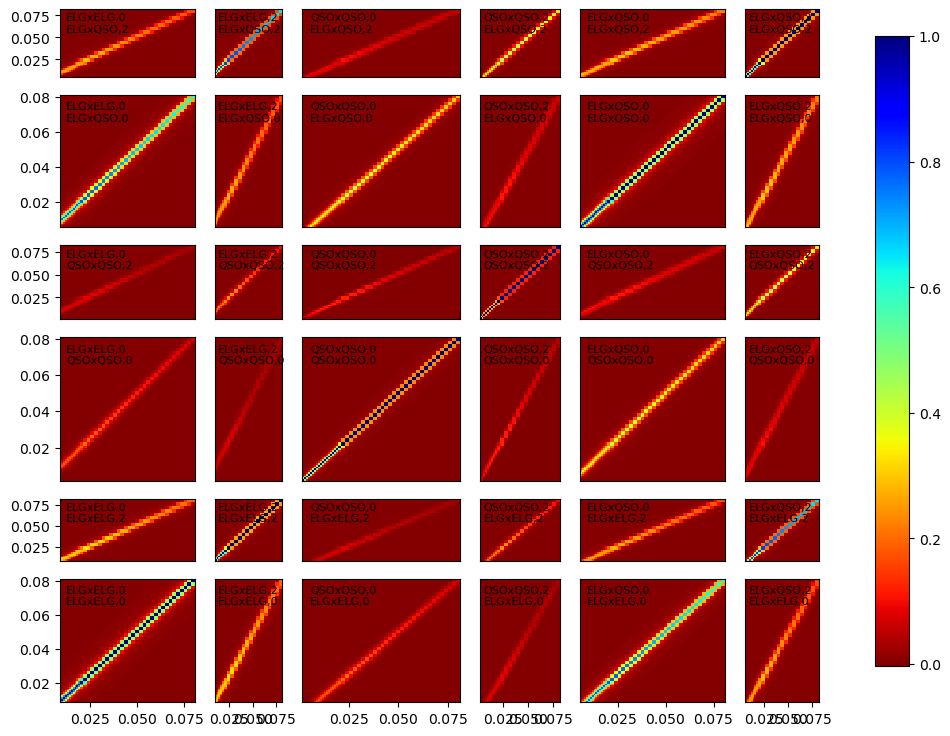

[000768.12] [0/1] 04-10 18:38  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'ELG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'ELG_ell0.sn0', 'ELG_ell0.b1', 'ELG_ell0.sigmas'].
[000768.97] [0/1] 04-10 18:38  MinuitProfiler            INFO     Successfully jit input likelihood.
[000785.98] [0/1] 04-10 18:38  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (205 - 9) = 373.53 / 196 = 1.91 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |   4.7   |  2.3  |
|   ELG_cross_ell0xQSO_cross_ell0.sn0    |  True  |  0.030  | 0.018 |
|         QSO_cross_ell0.sigmas          |  True  |  5.31   | 0.53  |
|              QSO_ell0.sn0              |  True  | -0.122  | 0.037 |
|              QSO_ell0.b1               |  True  |  3.148  | 0.033 |
|           

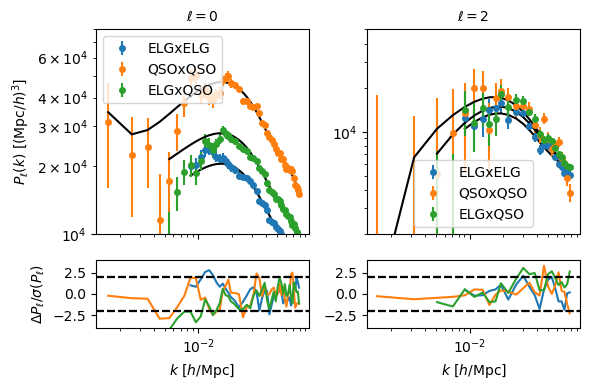

In [21]:
#order = ['LRGxELG', 'ELGxQSO']
orders = [['LRGxLRG', 'QSOxQSO', 'LRGxQSO'], ['LRGxLRG', 'ELGxELG', 'LRGxELG'], ['ELGxELG', 'QSOxQSO', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, observables, covs, zeffs, fiducial=fiducial, plot_cov=True)
    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# This does not work for now because I need to name differently the paramters name in the theory to have different bias /sigmas / as a funciton of the three likelihoods !


orders = [['LRGxLRG', 'ELGxELG','QSOxQSO', 'LRGxQSO', 'LRGxELG', 'ELGxQSO']]

for order in orders:
    likelihoods['-'.join(order)] = build_total_likelihood(order, observables, covs, zeffs, fiducial=fiducial, plot_cov=True)
    profilers['-'.join(order)] = run_profiler(likelihoods['-'.join(order)])
    plot_observables({tt: observables[tt] for tt in order})

In [ ]:
# We do not link the damping term from the cross-correlation and the auto-correlation
# Because they are different effective redshifts and we do not know the a priori.

In [172]:
# samplers = {}

# for tracer in likelihoods.keys():
#     logger.info(f'Run MCMC for {tracer=}:')
#     samplers[tracer] =  run_mcmc(likelihoods[tracer], max_iterations=20000, check_every=5000)

In [173]:
# from desilike.samples import Chain

# burnin, thin = 0.3, 10

# chains = {}

# #chains = Chain.concatenate([Chain.load(fn_chains[key].replace('*', str(i))).remove_burnin(burnin)[::thin] for i in range(nchains)])

# for tracer in samplers.keys():
#      chains[tracer] = Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in samplers[tracer].chains])
#      print(f'Nbr points for {tracer=}: {chains[tracer]["fnl_loc"].size}')

# params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas', 'QSO_ell0.b1', 'QSO_ell0.sn0', 'QSO_ell0.sigmas', 'QSO_cross_ell0.b1', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas']
# xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']

# plot_triangle([chains[tracer] for tracer in chains.keys()], params, legend_labels=list(chains.keys()), xlabels=xlabels, 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

# plot_triangle([chains[tracer] for tracer in chains.keys()], ['fnl_loc'], legend_labels=list(chains.keys()), xlabels=[r'$f_{\rm NL}^{\rm loc}$'], 
#               filled=[True]*len(chains), contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '-'])

In [174]:
# how will we do with the mocks? (I think nothing, it will straight forwards, like providing the mocks for each obseravble and desilike will take the standard deviation ect... ) --> no PROBLEME


In [175]:
## PLUS J4IA PAS UN BEAU PK ALORS QUE AVANT JEN AVAIS UN ! KEPASA ??   --> COMPARER AVEC DR2 FKP 

ParameterCollection(['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'])
[001672.45] [0/1] 04-10 16:23  MinuitProfiler            INFO     Varied parameters: ['fnl_loc', 'LRG_cross_ell0xQSO_cross_ell0.sn0', 'QSO_cross_ell0.sigmas', 'QSO_ell0.sn0', 'QSO_ell0.b1', 'QSO_ell0.sigmas', 'LRG_ell0.sn0', 'LRG_ell0.b1', 'LRG_ell0.sigmas'].
[001673.01] [0/1] 04-10 16:23  MinuitProfiler            INFO     Successfully jit input likelihood.
[001683.51] [0/1] 04-10 16:23  PNG fitting tools         INFO     
+----------------------------------------+--------+---------+-------+
| chi2 / (222 - 9) = 290.38 / 213 = 1.36 | varied | bestfit | error |
+----------------------------------------+--------+---------+-------+
|                fnl_loc                 |  True  |  -9.8   |  2.0  |
|   LRG_cross_ell0xQSO_cross_ell0.sn0    |  True  | -0.009  | 0.032 |
|         QSO_cross_ell0.si

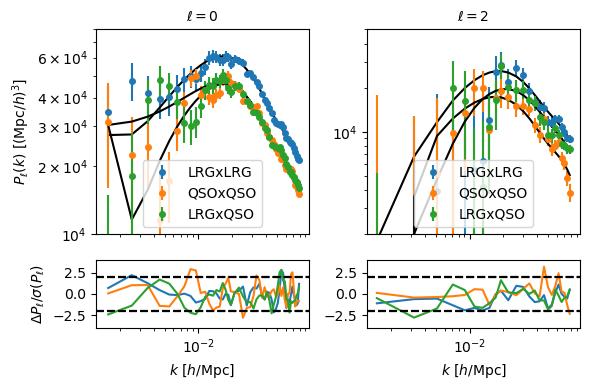

In [ ]:
from desilike.likelihoods import ObservablesGaussianLikelihood

total_likelihood = ObservablesGaussianLikelihood(observables=flatten_observables, covariance=cov_tot.value(), scale_covariance=1)

from clustering_statistics import tools  

for tracers in order: 
    tracers = tracers.split('x')

    if tracers[0] == tracers[1]: 
        if len(pks['x'.join(tracers)].ells) > 1:
            zeff = [windows['x'.join(tracers)].observable.get(ell).attrs['zeff'] for ell in [0,2]]
            alpha, beta = tools.bias(1, tracer=tracers[0], return_params=True)  # b(z) = alpha * (1 + z)**2 + beta
            factor = (alpha * (1 + zeff[1])**2 + beta) / (alpha * (1 + zeff[0])**2 + beta)
            total_likelihood.all_params[f"{tracers[0]}_ell2.b1"].update(derived='{' + f"{tracers[0]}_ell0.b1" + '}' + f' * {factor}')
            #logger.warning('we neglect the redshift dependence of the damping term, for now')
            total_likelihood.all_params[f"{tracers[0]}_ell2.sigmas"].update(derived='{' + f"{tracers[0]}_ell0.sigmas" + '}')

    # fix cross-correlation bias to the value derived from the auto-correlation:
    if tracers[0] != tracers[1]: 
        for tt in tracers:
            zeff_auto = windows['x'.join(2*[tt])].observable.get(0).attrs['zeff'] 
            zeff_cross = windows['x'.join(tracers)].observable.get(0).attrs['zeff']
            # print(zeff_auto, zeff_cross, tt + '_ell0.b1', tt + '_cross_ell0.b1')
            alpha, beta = tools.bias(1, tracer=tt, return_params=True)  # b(z) = alpha * (1 + z)**2 + beta
            factor = (alpha * (1 + zeff_cross)**2 + beta) / (alpha * (1 + zeff_auto)**2 + beta)
            total_likelihood.all_params[f'{tt}_cross_ell0.b1'].update(derived='{' + f'{tt}_ell0.b1' + '}' + f' * {factor}')

            if len(pks['x'.join(tracers)].ells) > 1:
                zeff_cross = windows['x'.join(tracers)].observable.get(2).attrs['zeff']
                factor = (alpha * (1 + zeff_cross)**2 + beta) / (alpha * (1 + zeff_auto)**2 + beta)
                total_likelihood.all_params[f'{tt}_cross_ell2.b1'].update(derived='{' + f'{tt}_ell0.b1' + '}' + f' * {factor}')

        # Do not link the damping term from the cross-correlation and the auto-correlation, because they are different effective redshifts.
        # So, we fix one of the two damping term to 0, and let the other one free.
        total_likelihood.all_params[f"{tracers[0]}_cross_ell0.sigmas"].update(value=0, fixed=True)
        if len(pks['x'.join(tracers)].ells) > 1:
            for tt in tracers:
                total_likelihood.all_params[f"{tt}_cross_ell2.sigmas"].update(derived='{' + f"{tt}_cross_ell0.sigmas" + '}')

print(total_likelihood.varied_params)

total_likelihood()



In [ ]:
import lsstypes 

seeds = [85, 95, 75, 65, 91, 37, 46, 87, 19, 38]

ttest = [lsstypes.read(stats_dir / f'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_NGC_weight-default-fkp-oqe_geometry_0_seed={seed}.h5') for seed in seeds]

ttest[2].value()

In [ ]:
## IMPORTANT COMMENT FAIRE POUR HARTLPA/PERCIVAL -> COMMENT DESILIKE DONNE LES VAEURS DE CHI2 (qui ne doit pas avoir percival)
# 
https://github.com/cosmodesi/desi-clustering/blob/7b1f38fcacbfa4ef815f56c345b5072f2a3a7d26/full_shape/tools.py#L301

In [14]:
tt = lsstypes.read(stats_dir / 'window_mesh2_spectrum_poles_fm_QSO_z0.8-3.5_SGC_weight-default-fkp-oqe_geometry_0_seed=1.h5')

In [15]:
tt.value()

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(157, 468))